In [1]:
# Cell 1 : Installing the package requirement
%pip install seaborn scipy statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 5.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/11.3 MB 3.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.3 MB 3.7 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.3 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/11.3 MB 3.6 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 3.5 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.3 MB 3.4 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.3 MB 3.4 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.3 MB 3.4 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.3 MB 3.1 MB/s eta 0:00:02
   ------------------------- -------------- 7.3/11.3 MB 3.1 MB/s eta 0:00:02
   --------------------------- ------------ 7.9/11.3 MB 3.1 MB/s eta 0:00:02
   ---

In [2]:
# Cell 2: Import package
import sys
from pathlib import Path
from importlib.metadata import version

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

In [3]:
# Cell 3: Load dataset

df_raw = pd.read_csv(
    "DataSet.csv",
    dtype={"Student ID": "string"}
)

df = df_raw.copy(deep=True)

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

display(df.head())

Number of rows: 30
Number of columns: 5


,Student ID,Study Hours (per week),Attendance Rate (%),Work Hours (per week),Current GPA (0-4 scale)
0,1,15,95,0,3.8
1,2,10,80,15,3.0
2,3,25,100,8,4.0
3,4,5,50,25,2.1
4,5,12,85,12,3.2


In [4]:
# Cell 4: Check data types, missing values, and duplicates.

quality_check = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Missing values": df.isna().sum(),
    "Unique values": df.nunique()
})

display(quality_check)

duplicate_rows = df.duplicated().sum()
print(f"\nAdditional identical rows: {duplicate_rows}")

duplicate_ids = df["Student ID"].dropna().duplicated().sum()
print(f"Repeated Student IDs: {duplicate_ids}")

,Data type,Missing values,Unique values
Student ID,string,0,30
Study Hours (per week),int64,0,21
Attendance Rate (%),int64,0,27
Work Hours (per week),int64,0,24
Current GPA (0-4 scale),float64,0,21



Additional identical rows: 0
Repeated Student IDs: 0


In [5]:
# Cell 5: Check whether numerical values fall within valid ranges.

valid_ranges = {
    "Study Hours (per week)": (0, 168),
    "Attendance Rate (%)": (0, 100),
    "Work Hours (per week)": (0, 168),
    "Current GPA (0-4 scale)": (0, 4)
}

range_summary = []

for column, (minimum, maximum) in valid_ranges.items():

    outside_range = df[column].notna() & (
        (df[column] < minimum) | (df[column] > maximum)
    )

    range_summary.append({
        "Variable": column,
        "Valid range": f"{minimum} to {maximum}",
        "Out-of-range values": int(outside_range.sum())
    })

    if outside_range.any():
        print(f"\nCheck these records for {column}:")
        display(df.loc[outside_range, ["Student ID", column]])

# Display the overall results.
display(pd.DataFrame(range_summary))

,Variable,Valid range,Out-of-range values
0,Study Hours (per week),0 to 168,0
1,Attendance Rate (%),0 to 100,0
2,Work Hours (per week),0 to 168,0
3,Current GPA (0-4 scale),0 to 4,0


In [6]:
# Cell 6: Calculate descriptive statistics.

# Select the four measurements for analysis.
analysis_columns = [
    "Study Hours (per week)",
    "Attendance Rate (%)",
    "Work Hours (per week)",
    "Current GPA (0-4 scale)"
]

# Calculate summary statistics.
# .T places each variable on its own row.
descriptive_stats = df[analysis_columns].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T

# Use clear column labels.
descriptive_stats.columns = [
    "N", "Mean", "Median", "SD", "Minimum", "Maximum"
]

# Display the number of observations as a whole number.
descriptive_stats["N"] = descriptive_stats["N"].astype(int)

# Round the displayed results while retaining the original precision.
display(descriptive_stats.round(2))

,N,Mean,Median,SD,Minimum,Maximum
Study Hours (per week),30,13.47,13.5,6.03,4.0,25.0
Attendance Rate (%),30,80.70,84.5,16.01,40.0,100.0
Work Hours (per week),30,14.03,13.5,8.42,0.0,30.0
Current GPA (0-4 scale),30,3.14,3.2,0.65,1.9,4.0


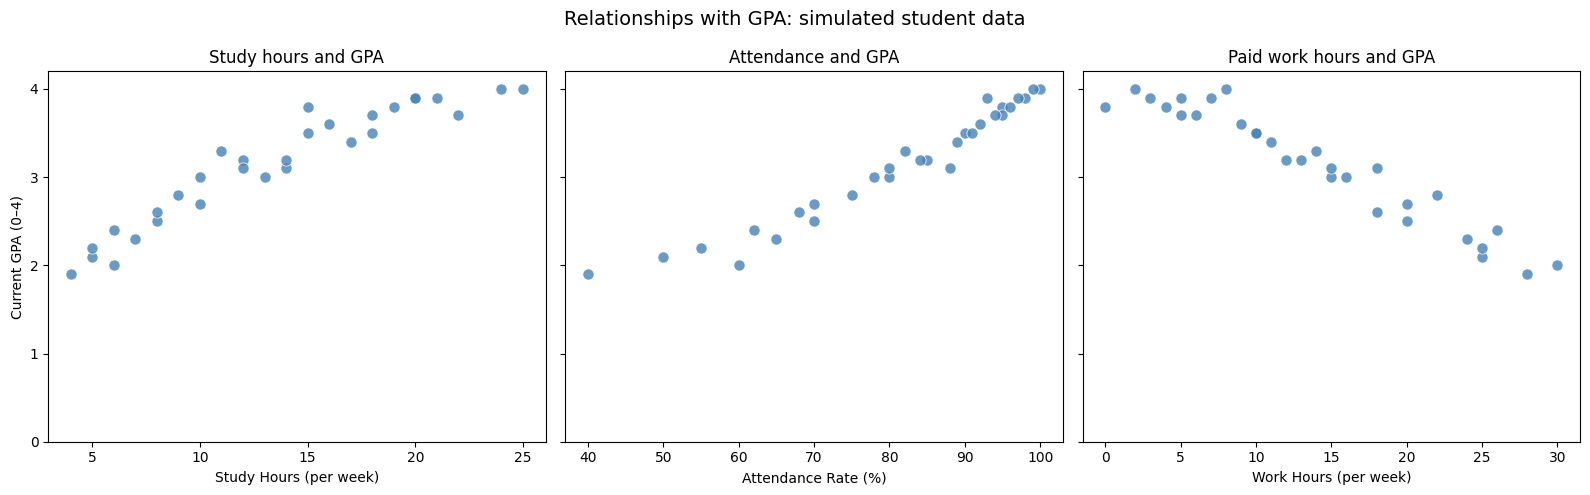

In [7]:
# Cell 7: Visualise the relationships between each predictor and GPA.

plot_settings = [
    ("Study Hours (per week)", "Study hours and GPA"),
    ("Attendance Rate (%)", "Attendance and GPA"),
    ("Work Hours (per week)", "Paid work hours and GPA")
]

# Create three charts with a shared GPA scale.
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    sharey=True
)

# Draw one scatterplot for each predictor.
for ax, (column, title) in zip(axes, plot_settings):

    sns.scatterplot(
        data=df,
        x=column,
        y="Current GPA (0-4 scale)",
        ax=ax,
        color="steelblue",
        s=65,
        alpha=0.8
    )

    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Current GPA (0–4)")
    ax.set_ylim(0, 4.2)
    ax.set_yticks([0, 1, 2, 3, 4])

fig.suptitle("Relationships with GPA: simulated student data", fontsize=14)
fig.tight_layout()
plt.show()

In [8]:
# Cell 8: Calculate Pearson correlations.

# Calculate correlations among the four measurements.
pearson_matrix = df[analysis_columns].corr(method="pearson")

print("Pearson correlation matrix:")
display(pearson_matrix.round(3))

# Examine each predictor's relationship with GPA.
outcome = "Current GPA (0-4 scale)"
correlation_rows = []

for predictor in analysis_columns:
    if predictor == outcome:
        continue

    # Use records with both measurements available.
    paired_data = df[[predictor, outcome]].dropna()

    # Calculate Pearson's r and a two-sided p-value.
    r, p = stats.pearsonr(
        paired_data[predictor],
        paired_data[outcome],
        alternative="two-sided"
    )

    correlation_rows.append({
        "Predictor": predictor,
        "N": len(paired_data),
        "Pearson r": r,
        "p-value": p
    })

# Retain the numerical results at full precision.
correlation_results = pd.DataFrame(correlation_rows)

# Create a separate copy for readable display.
correlation_display = correlation_results.copy()
correlation_display["Pearson r"] = (
    correlation_display["Pearson r"].round(3)
)

# Display very small p-values without rounding them to zero.
correlation_display["p-value"] = (
    correlation_display["p-value"].apply(
        lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
    )
)

print("\nCorrelations with GPA:")
display(correlation_display)

Pearson correlation matrix:


,Study Hours (per week),Attendance Rate (%),Work Hours (per week),Current GPA (0-4 scale)
Study Hours (per week),1.000,0.922,-0.895,0.949
Attendance Rate (%),0.922,1.000,-0.926,0.972
Work Hours (per week),-0.895,-0.926,1.000,-0.966
Current GPA (0-4 scale),0.949,0.972,-0.966,1.000



Correlations with GPA:


,Predictor,N,Pearson r,p-value
0,Study Hours (per week),30,0.949,<0.001
1,Attendance Rate (%),30,0.972,<0.001
2,Work Hours (per week),30,-0.966,<0.001


In [9]:
# Cell 9: Fit a multiple linear regression model.

# Define the three predictors and the outcome.
predictor_columns = [
    "Study Hours (per week)",
    "Attendance Rate (%)",
    "Work Hours (per week)"
]

outcome = "Current GPA (0-4 scale)"

# Use records with all four measurements available.
regression_data = df[predictor_columns + [outcome]].dropna().copy()

# X contains the predictors; y contains GPA.
X = regression_data[predictor_columns]
y = regression_data[outcome]

# Add the intercept, which appears as "const" in the output.
X = sm.add_constant(X)

# Fit the model using Ordinary Least Squares (OLS).
regression_model = sm.OLS(y, X, missing="raise").fit()

# Report how many records entered the model.
print(f"Records used: {int(regression_model.nobs)}")
print(
    "Records excluded because of missing values:",
    len(df) - len(regression_data)
)

# Display coefficients, confidence intervals, and model statistics.
print(regression_model.summary())

Records used: 30
Records excluded because of missing values: 0
                               OLS Regression Results                              
Dep. Variable:     Current GPA (0-4 scale)   R-squared:                       0.984
Model:                                 OLS   Adj. R-squared:                  0.982
Method:                      Least Squares   F-statistic:                     517.0
Date:                     Sun, 13 Sep 2026   Prob (F-statistic):           2.76e-23
Time:                             15:12:08   Log-Likelihood:                 32.276
No. Observations:                       30   AIC:                            -56.55
Df Residuals:                           26   BIC:                            -50.95
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------

In [10]:
# Cell 10: Check multicollinearity using VIF.

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Reuse X from Cell 9, including its intercept.
X_values = X.to_numpy(dtype=float)

vif_rows = []

# Calculate VIF for each predictor.
for index, column in enumerate(X.columns):

    # Keep the intercept in the calculation,
    # but report VIF only for the three predictors.
    if column == "const":
        continue

    vif_rows.append({
        "Predictor": column,
        "VIF": variance_inflation_factor(X_values, index)
    })

# Retain full precision and round only for display.
vif_results = pd.DataFrame(vif_rows)

print("Multicollinearity check:")
display(vif_results.round(2))

Multicollinearity check:


,Predictor,VIF
0,Study Hours (per week),7.22
1,Attendance Rate (%),10.18
2,Work Hours (per week),7.65


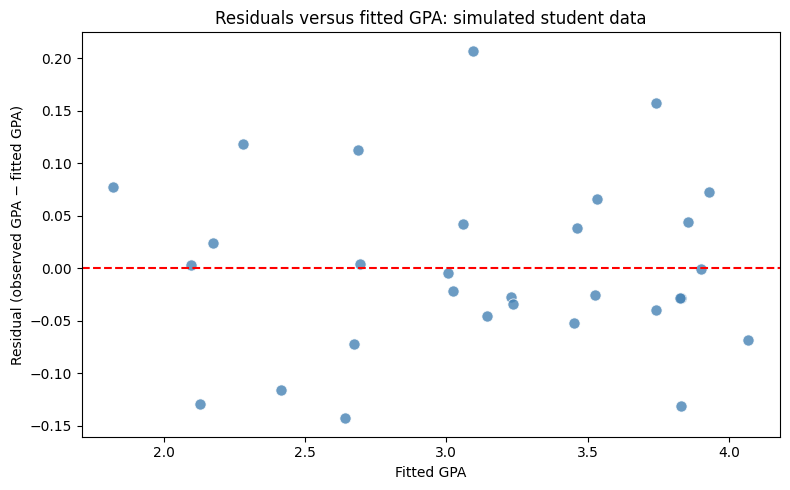

In [11]:
# Extract fitted GPA values and residuals from our existing model
fitted_gpa = regression_model.fittedvalues
residuals = regression_model.resid

# Plot residuals against fitted GPA
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    x=fitted_gpa,
    y=residuals,
    ax=ax,
    color="steelblue",
    s=65,
    alpha=0.8
)

# A residual of zero means observed GPA equals fitted GPA
ax.axhline(y=0, color="red", linestyle="--", linewidth=1.5)

ax.set_xlabel("Fitted GPA")
ax.set_ylabel("Residual (observed GPA − fitted GPA)")
ax.set_title("Residuals versus fitted GPA: simulated student data")

fig.tight_layout()
plt.show()

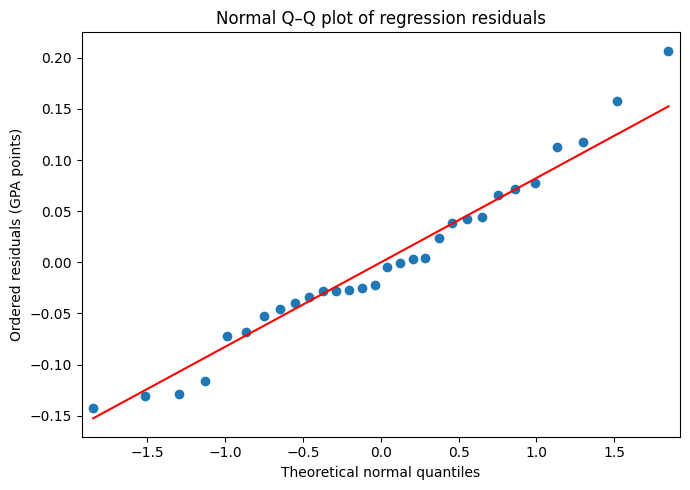

In [12]:
# Compare our regression residuals with a normal distribution
fig, ax = plt.subplots(figsize=(7, 5))

sm.qqplot(
    residuals,
    line="s",
    ax=ax
)

ax.set_title("Normal Q–Q plot of regression residuals")
ax.set_xlabel("Theoretical normal quantiles")
ax.set_ylabel("Ordered residuals (GPA points)")

fig.tight_layout()
plt.show()

In [13]:
# Extract the 95% confidence intervals
ci_95 = regression_model.conf_int(alpha=0.05)

# Keep the results at full precision
regression_results = pd.DataFrame({
    "B": regression_model.params,
    "SE": regression_model.bse,
    "95% CI lower": ci_95[0],
    "95% CI upper": ci_95[1],
    "p-value": regression_model.pvalues
})

regression_results = regression_results.rename(
    index={"const": "Intercept"}
)
regression_results.index.name = "Term"

# Create a rounded display copy
regression_display = regression_results.round(3)

# Format p-values from the original, unrounded values
regression_display["p-value"] = regression_results["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
)

print("Multiple linear regression: current GPA")
display(regression_display)

# Show the overall model fit
print(f"N = {int(regression_model.nobs)}")
print(f"R² = {regression_model.rsquared:.3f}")
print(f"Adjusted R² = {regression_model.rsquared_adj:.3f}")

Multiple linear regression: current GPA


,B,SE,95% CI lower,95% CI upper,p-value
Term,,,,,
Intercept,1.938,0.291,1.339,2.536,<0.001
Study Hours (per week),0.026,0.007,0.011,0.041,0.001
Attendance Rate (%),0.016,0.003,0.009,0.022,<0.001
Work Hours (per week),-0.030,0.005,-0.041,-0.019,<0.001


N = 30
R² = 0.984
Adjusted R² = 0.982
